# BigMart Sales – v8 · Richer Meta + New Features + Clip + Pseudo-label
## Target Encoding + Grocery Split + XGB/LGB/CatBoost Stack + Optuna

**Changes vs 07:**
1. `FeatureEngineer` — 2 new features: `Outlet_Age_x_Type`, `Weight_x_MRP`
2. `StackingEnsemble` — meta gets OOF + `Item_MRP` + `TE_Outlet_Identifier`
3. `Preprocessor` — `Outlet_Size_Was_Missing` flag before imputation
4. Prediction clipped at min 33
5. Pseudo-labelling round on confident test rows

**Metric:** RMSE on raw sales (models trained on log1p target)


## 0 · Install Dependencies

## 1 · Imports & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

import xgboost  as xgb
import lightgbm as lgb
import catboost as cbt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.base             import BaseEstimator, TransformerMixin
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.linear_model     import BayesianRidge
from sklearn.model_selection  import KFold
from sklearn.metrics          import mean_squared_error
from sklearn.inspection       import permutation_importance

TRAIN_PATH = 'data/train_v9rqX0R.csv'
TEST_PATH  = 'data/test_AbJTz2l.csv'
SUB_PATH   = 'data/sample_submission_8RXa3c6.csv'
OUT_PATH   = 'outputs/submission_bigmart_v8.csv'

N_FOLDS          = 5
SEED             = 42
N_TRIALS_MAIN    = 100
N_TRIALS_GROCERY = 100  # raised from 60 — small data needs more tuning

os.makedirs('outputs', exist_ok=True)
np.random.seed(SEED)

print(f'XGBoost  {xgb.__version__}')
print(f'LightGBM {lgb.__version__}')
print(f'CatBoost {cbt.__version__}')
print(f'Optuna   {optuna.__version__}')


XGBoost  3.2.0
LightGBM 4.6.0
CatBoost 1.2.10
Optuna   4.8.0


## 2 · DataLoader

In [2]:
class DataLoader:
    def __init__(self, train_path: str, test_path: str):
        self.train_path = train_path
        self.test_path  = test_path

    def load(self):
        train = pd.read_csv(self.train_path)
        test  = pd.read_csv(self.test_path)
        train['_split'] = 'train'
        test['_split']  = 'test'
        print(f'[DataLoader] train={train.shape}  test={test.shape}')
        return train, test

loader = DataLoader(TRAIN_PATH, TEST_PATH)
train_raw, test_raw = loader.load()


[DataLoader] train=(8523, 13)  test=(5681, 12)


## 3 · Preprocessor

In [3]:
class Preprocessor(BaseEstimator, TransformerMixin):
    _FAT_MAP = {'low fat':'Low Fat', 'LF':'Low Fat', 'reg':'Regular'}

    def __init__(self):
        self._item_weight_map  = {}
        self._global_weight    = 0.0
        self._item_vis_map     = {}
        self._outlet_size_map  = {}

    def fit(self, df, y=None):
        tmp = df.copy()
        tmp['Item_Fat_Content'] = tmp['Item_Fat_Content'].replace(self._FAT_MAP)
        self._item_weight_map = tmp.groupby('Item_Identifier')['Item_Weight'].mean().to_dict()
        self._global_weight   = tmp['Item_Weight'].mean()
        vis = tmp.copy()
        vis.loc[vis['Item_Visibility'] == 0, 'Item_Visibility'] = np.nan
        self._item_vis_map    = vis.groupby('Item_Identifier')['Item_Visibility'].mean().to_dict()
        self._outlet_size_map = (
            tmp.dropna(subset=['Outlet_Size'])
               .groupby('Outlet_Type')['Outlet_Size']
               .agg(lambda x: x.mode().iloc[0]).to_dict()
        )
        return self

    def transform(self, df):
        df = df.copy()
        df['Item_Fat_Content'] = df['Item_Fat_Content'].replace(self._FAT_MAP)
        df['Item_Weight'] = df.apply(
            lambda r: self._item_weight_map.get(r['Item_Identifier'], self._global_weight)
                      if pd.isna(r['Item_Weight']) else r['Item_Weight'], axis=1)
        df['Item_Visibility'] = df.apply(
            lambda r: self._item_vis_map.get(r['Item_Identifier'], r['Item_Visibility'])
                      if r['Item_Visibility'] == 0 else r['Item_Visibility'], axis=1)
        # flag before imputation
        df['Outlet_Size_Was_Missing'] = df['Outlet_Size'].isna().astype(int)
        df['Outlet_Size'] = df.apply(
            lambda r: self._outlet_size_map.get(r['Outlet_Type'], 'Small')
                      if pd.isna(r['Outlet_Size']) else r['Outlet_Size'], axis=1)
        return df

combined_raw = pd.concat([train_raw, test_raw], ignore_index=True, sort=False)
prep = Preprocessor()
prep.fit(combined_raw)
train_clean = prep.transform(train_raw)
test_clean  = prep.transform(test_raw)
combined    = pd.concat([train_clean, test_clean], ignore_index=True, sort=False)
print('Missing post-preprocessing:', combined[['Item_Weight','Item_Visibility','Outlet_Size']].isnull().sum().to_dict())
print('Outlet_Size_Was_Missing counts:', combined['Outlet_Size_Was_Missing'].value_counts().to_dict())


Missing post-preprocessing: {'Item_Weight': 0, 'Item_Visibility': 0, 'Outlet_Size': 0}
Outlet_Size_Was_Missing counts: {0: 10188, 1: 4016}


## 4 · FeatureEngineer

In [4]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    _ORDINAL_SIZE     = {'Small':0,'Medium':1,'High':2}
    _ORDINAL_LOCATION = {'Tier 3':0,'Tier 2':1,'Tier 1':2}
    _OUTLET_TYPE_ORD  = {'Grocery Store':0,'Supermarket Type1':1,
                         'Supermarket Type2':2,'Supermarket Type3':3}
    _DROP = ['Item_Identifier','Outlet_Identifier',
             'Outlet_Establishment_Year','_split']

    def __init__(self):
        self._label_encoders = {}
        self._item_vis_mean  = {}
        self._mrp_type_mean  = {}

    def fit(self, df, y=None):
        tmp = self._static(df.copy())
        self._item_vis_mean = df.groupby('Item_Identifier')['Item_Visibility'].mean().to_dict()
        self._mrp_type_mean = df.groupby('Item_Type')['Item_MRP'].mean().to_dict()
        obj_cols = [c for c in tmp.select_dtypes('object').columns
                    if c not in ['Item_Outlet_Sales','Item_Identifier','Outlet_Identifier','_split']]
        for col in obj_cols:
            le = LabelEncoder()
            le.fit(tmp[col].astype(str))
            self._label_encoders[col] = le
        return self

    def transform(self, df):
        df = df.copy()
        df = self._static(df)
        df['Item_Visibility_MeanRatio'] = df.apply(
            lambda r: r['Item_Visibility'] /
                      self._item_vis_mean.get(r['Item_Identifier'], r['Item_Visibility']+1e-6), axis=1)
        df['MRP_Per_Category'] = df.apply(
            lambda r: r['Item_MRP'] / self._mrp_type_mean.get(r['Item_Type'], r['Item_MRP']+1e-6), axis=1)
        df['Item_Cat_x_Outlet'] = df['Item_Category'].astype(str) + '_' + df['Outlet_Type'].astype(str)

        # NEW: outlet age × outlet type interaction
        df['Outlet_Age_x_Type'] = df['Outlet_Age'] * df['Outlet_Type'].map(self._OUTLET_TYPE_ORD).fillna(0)
        # NEW: item weight × MRP interaction
        df['Weight_x_MRP'] = df['Item_Weight'] * df['Item_MRP']

        df.drop(columns=[c for c in self._DROP if c in df.columns], inplace=True)

        obj_cols = [c for c in df.select_dtypes('object').columns
                    if c not in ['Item_Outlet_Sales']]
        for col in obj_cols:
            if col in self._label_encoders:
                df[col] = self._label_encoders[col].transform(df[col].astype(str))
            else:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
        return df

    @classmethod
    def _static(cls, df):
        df['Outlet_Age']           = 2013 - df['Outlet_Establishment_Year']
        df['Item_Category']        = df['Item_Identifier'].str[:2]
        df.loc[df['Item_Category']=='NC','Item_Fat_Content'] = 'Non-Edible'
        df['Log_Item_Visibility']  = np.log1p(df['Item_Visibility'])
        df['MRP_Bin']              = pd.qcut(df['Item_MRP'], q=16, labels=False, duplicates='drop')
        df['MRP_x_OutletType']     = df['Item_MRP'] * df['Outlet_Type'].map(cls._OUTLET_TYPE_ORD).fillna(0)
        df['Is_Grocery']           = (df['Outlet_Type'] == 'Grocery Store').astype(int)
        df['Outlet_Size']          = df['Outlet_Size'].map(cls._ORDINAL_SIZE)
        df['Outlet_Location_Type'] = df['Outlet_Location_Type'].map(cls._ORDINAL_LOCATION)
        return df

fe = FeatureEngineer()
fe.fit(combined)
train_fe = fe.transform(train_clean)
test_fe  = fe.transform(test_clean)
print('Features after engineering:', [c for c in train_fe.columns if c != 'Item_Outlet_Sales'])
print(f'Shape: train={train_fe.shape}  test={test_fe.shape}')


Features after engineering: ['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Outlet_Size_Was_Missing', 'Outlet_Age', 'Item_Category', 'Log_Item_Visibility', 'MRP_Bin', 'MRP_x_OutletType', 'Is_Grocery', 'Item_Visibility_MeanRatio', 'MRP_Per_Category', 'Item_Cat_x_Outlet', 'Outlet_Age_x_Type', 'Weight_x_MRP']
Shape: train=(8523, 21)  test=(5681, 20)


## 5 · KFoldTargetEncoder

In [5]:
class KFoldTargetEncoder(BaseEstimator, TransformerMixin):
    """
    Leak-free mean target encoding using K-Fold.

    For TRAIN rows: each row is encoded using the target mean computed
    on the *other* K-1 folds (out-of-fold), preventing leakage.
    For TEST rows:  use the global mean computed on the full training set.

    Smoothing formula:
        encoded = (count × mean + alpha × global_mean) / (count + alpha)
    where alpha controls regularisation (higher = more shrinkage toward global mean).

    Columns encoded: Item_Identifier, Outlet_Identifier, Item_Type,
                     Item_Category, Item_Cat_x_Outlet
    """
    ENCODE_COLS = ['Item_Identifier', 'Outlet_Identifier',
                   'Item_Type', 'Item_Category', 'Item_Cat_x_Outlet']

    def __init__(self, n_folds: int = 5, alpha: float = 10.0, seed: int = 42):
        self.n_folds = n_folds
        self.alpha   = alpha
        self.seed    = seed
        self._global_mean  = 0.0
        self._encode_maps  = {}   # col → {category: smoothed_mean}

    def fit(self, train_df, target_series):
        """Compute test-time encoding maps from full training data."""
        self._global_mean = target_series.mean()
        for col in self.ENCODE_COLS:
            if col not in train_df.columns:
                continue
            stats = target_series.groupby(train_df[col]).agg(['sum','count'])
            smoothed = ((stats['sum'] + self.alpha * self._global_mean) /
                        (stats['count'] + self.alpha))
            self._encode_maps[col] = smoothed.to_dict()
        return self

    def transform_train(self, train_df, target_series) -> pd.DataFrame:
        """OOF encoding for training rows — no leakage."""
        df = train_df.copy()
        kf = KFold(self.n_folds, shuffle=True, random_state=self.seed)
        for col in self.ENCODE_COLS:
            if col not in df.columns:
                continue
            enc = np.full(len(df), self._global_mean, dtype=np.float64)
            for tr_idx, va_idx in kf.split(df):
                tr_target = target_series.iloc[tr_idx]
                tr_col    = df[col].iloc[tr_idx]
                stats     = tr_target.groupby(tr_col).agg(['sum','count'])
                smoothed  = ((stats['sum'] + self.alpha * self._global_mean) /
                             (stats['count'] + self.alpha))
                enc[va_idx] = df[col].iloc[va_idx].map(smoothed).fillna(self._global_mean).values
            df[f'TE_{col}'] = enc
        return df

    def transform_test(self, test_df) -> pd.DataFrame:
        """Use full-train maps for test rows."""
        df = test_df.copy()
        for col in self.ENCODE_COLS:
            if col not in df.columns:
                continue
            df[f'TE_{col}'] = df[col].map(self._encode_maps.get(col, {})).fillna(self._global_mean)
        return df

# We need original identifier columns still present at this stage
# Re-build from clean data keeping identifiers
def rebuild_with_identifiers(clean_df, fe: FeatureEngineer):
    """Apply FE but retain identifier columns for target encoding."""
    df = clean_df.copy()
    # static features
    df = FeatureEngineer._static(df)
    # visibility ratio & mrp per category
    df['Item_Visibility_MeanRatio'] = df.apply(
        lambda r: r['Item_Visibility'] /
                  fe._item_vis_mean.get(r['Item_Identifier'], r['Item_Visibility']+1e-6), axis=1)
    df['MRP_Per_Category'] = df.apply(
        lambda r: r['Item_MRP'] / fe._mrp_type_mean.get(r['Item_Type'], r['Item_MRP']+1e-6), axis=1)
    df['Item_Cat_x_Outlet'] = df['Item_Category'].astype(str) + '_' + df['Outlet_Type'].astype(str)
    return df   # identifiers still present, encoding not yet applied

train_with_ids = rebuild_with_identifiers(train_clean, fe)
test_with_ids  = rebuild_with_identifiers(test_clean,  fe)

TARGET = 'Item_Outlet_Sales'
log_target = np.log1p(train_with_ids[TARGET])

te = KFoldTargetEncoder(n_folds=N_FOLDS, alpha=10.0, seed=SEED)
te.fit(train_with_ids, log_target)

train_te = te.transform_train(train_with_ids, log_target)
test_te  = te.transform_test(test_with_ids)

# Now drop identifiers & apply label encoding to remaining object cols
DROP_COLS = ['Item_Identifier','Outlet_Identifier','Outlet_Establishment_Year','_split']
TE_COLS   = KFoldTargetEncoder.ENCODE_COLS

def finalize(df, fe, drop_cols, te_source_cols):
    df = df.copy()
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
    # drop original cols that were target-encoded (keep TE_ versions)
    df.drop(columns=[c for c in te_source_cols if c in df.columns], inplace=True)
    obj_cols = [c for c in df.select_dtypes('object').columns if c not in [TARGET]]
    for col in obj_cols:
        if col in fe._label_encoders:
            df[col] = fe._label_encoders[col].transform(df[col].astype(str))
        else:
            df[col] = LabelEncoder().fit_transform(df[col].astype(str))
    return df

train_final = finalize(train_te, fe, DROP_COLS, TE_COLS)
test_final  = finalize(test_te,  fe, DROP_COLS, TE_COLS)

FEATURES = [c for c in train_final.columns if c != TARGET]
print(f'Final features ({len(FEATURES)}):')
print(FEATURES)
print(f'train={train_final.shape}  test={test_final.shape}')


Final features (20):
['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_MRP', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Outlet_Size_Was_Missing', 'Outlet_Age', 'Log_Item_Visibility', 'MRP_Bin', 'MRP_x_OutletType', 'Is_Grocery', 'Item_Visibility_MeanRatio', 'MRP_Per_Category', 'TE_Item_Identifier', 'TE_Outlet_Identifier', 'TE_Item_Type', 'TE_Item_Category', 'TE_Item_Cat_x_Outlet']
train=(8523, 21)  test=(5681, 20)


## 6 · GrocerySplitter

In [6]:
class GrocerySplitter:
    """
    Splits data into Grocery Store and Supermarket subsets.
    Grocery Store sales are 3-4× lower and have a very different distribution.
    Training separate models prevents the model from compromising between
    the two very different sales scales.
    """
    GROCERY_COL = 'Is_Grocery'

    def split(self, df: pd.DataFrame, features: list):
        grocery_mask = df[self.GROCERY_COL] == 1
        return {
            'grocery'     : df[grocery_mask].reset_index(drop=True),
            'supermarket' : df[~grocery_mask].reset_index(drop=True),
        }

    def split_xy(self, df: pd.DataFrame, features: list, target: str):
        splits = self.split(df, features)
        result = {}
        for name, sub in splits.items():
            result[name] = {
                'X': sub[features].values,
                'y': np.log1p(sub[target].values),
                'df': sub,
            }
        return result

splitter = GrocerySplitter()
splits   = splitter.split_xy(train_final, FEATURES, TARGET)

print('Grocery    train rows :', len(splits['grocery']['y']))
print('Supermarket train rows:', len(splits['supermarket']['y']))
print()
print('Grocery    sales  mean:', np.expm1(splits['grocery']['y']).mean().round(2))
print('Supermarket sales mean:', np.expm1(splits['supermarket']['y']).mean().round(2))

# Test split
test_grocery_mask = test_final['Is_Grocery'] == 1
X_test_grocery     = test_final[FEATURES][test_grocery_mask].values
X_test_supermarket = test_final[FEATURES][~test_grocery_mask].values
print()
print('Grocery    test rows :', X_test_grocery.shape[0])
print('Supermarket test rows:', X_test_supermarket.shape[0])


Grocery    train rows : 1083
Supermarket train rows: 7440

Grocery    sales  mean: 339.83
Supermarket sales mean: 2449.34

Grocery    test rows : 722
Supermarket test rows: 4959


## 7 · OptunaTuner (generic — works for XGB / LGB / CatBoost)

In [7]:
class OptunaTuner:
    def __init__(self, model_type: str, n_trials: int = 100,
                 n_folds: int = 5, seed: int = 42):
        assert model_type in ('xgb','lgb','cat')
        self.model_type = model_type
        self.n_trials   = n_trials
        self.n_folds    = n_folds
        self.seed       = seed
        self.study      = None
        self.best_params_: dict = {}

    def _suggest_xgb(self, trial):
        return {
            'n_estimators'      : trial.suggest_int  ('n_estimators',   300, 2000),
            'max_depth'         : trial.suggest_int  ('max_depth',        3,   10),
            'learning_rate'     : trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
            'subsample'         : trial.suggest_float('subsample',       0.5, 1.0),
            'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),   # floor raised
            'colsample_bylevel' : trial.suggest_float('colsample_bylevel',0.5, 1.0),   # floor raised
            'min_child_weight'  : trial.suggest_int  ('min_child_weight',  1,  20),
            'gamma'             : trial.suggest_float('gamma',           0.0, 1.0),    # narrowed
            'reg_alpha'         : trial.suggest_float('reg_alpha',      1e-8,10.0, log=True),
            'reg_lambda'        : trial.suggest_float('reg_lambda',     1e-8,10.0, log=True),
            'tree_method': 'hist', 'random_state': self.seed,
            'n_jobs': -1, 'verbosity': 0,
        }

    def _suggest_lgb(self, trial):
        return {
            'n_estimators'      : trial.suggest_int  ('n_estimators',   300, 2000),
            'max_depth'         : trial.suggest_int  ('max_depth',        3,   12),
            'learning_rate'     : trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
            'num_leaves'        : trial.suggest_int  ('num_leaves',      20,  300),
            'subsample'         : trial.suggest_float('subsample',       0.5,  1.0),
            'colsample_bytree'  : trial.suggest_float('colsample_bytree',0.4,  1.0),
            'min_child_samples' : trial.suggest_int  ('min_child_samples', 5,  100),
            'reg_alpha'         : trial.suggest_float('reg_alpha',      1e-8, 10.0, log=True),
            'reg_lambda'        : trial.suggest_float('reg_lambda',     1e-8, 10.0, log=True),
            'min_split_gain'    : trial.suggest_float('min_split_gain',  0.0,  1.0),
            'random_state': self.seed, 'n_jobs': -1, 'verbosity': -1,
        }

    def _suggest_cat(self, trial):
        return {
            'iterations'        : trial.suggest_int  ('iterations',     300, 2000),
            'depth'             : trial.suggest_int  ('depth',            3,   10),
            'learning_rate'     : trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
            'l2_leaf_reg'       : trial.suggest_float('l2_leaf_reg',   1e-8, 10.0, log=True),
            'bagging_temperature': trial.suggest_float('bagging_temperature',0.0,1.0),
            'random_strength'   : trial.suggest_float('random_strength', 0.0, 10.0),
            'border_count'      : trial.suggest_int  ('border_count',    32,  255),
            'random_seed': self.seed, 'verbose': 0, 'allow_writing_files': False,
        }

    def _make_model(self, params):
        if self.model_type == 'xgb': return xgb.XGBRegressor(**params)
        if self.model_type == 'lgb': return lgb.LGBMRegressor(**params)
        if self.model_type == 'cat': return cbt.CatBoostRegressor(**params)

    def _suggest(self, trial):
        if self.model_type == 'xgb': return self._suggest_xgb(trial)
        if self.model_type == 'lgb': return self._suggest_lgb(trial)
        if self.model_type == 'cat': return self._suggest_cat(trial)

    def _objective(self, trial, X, y):
        params = self._suggest(trial)
        kf = KFold(self.n_folds, shuffle=True, random_state=self.seed)
        oof = np.zeros(len(y))
        for step, (tr, va) in enumerate(kf.split(X)):
            m = self._make_model(params)
            m.fit(X[tr], y[tr])
            oof[va] = m.predict(X[va])
            trial.report(np.sqrt(mean_squared_error(y[va], oof[va])), step=step)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()
        return np.sqrt(mean_squared_error(y, oof))

    def tune(self, X, y, study_name: str = '') -> dict:
        sampler = optuna.samplers.TPESampler(seed=self.seed)
        pruner  = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2)
        self.study = optuna.create_study(direction='minimize', sampler=sampler,
                                         pruner=pruner, study_name=study_name)
        self.study.optimize(lambda t: self._objective(t, X, y),
                            n_trials=self.n_trials, show_progress_bar=True)
        self.best_params_ = self._suggest_fixed(self.study.best_params)
        print(f'[{study_name}] best OOF RMSE (log): {self.study.best_value:.5f}  '
              f'→ raw: {np.expm1(self.study.best_value):,.1f}')
        return self.best_params_

    def _suggest_fixed(self, best):
        if self.model_type == 'xgb':
            best.update({'tree_method':'hist','random_state':self.seed,'n_jobs':-1,'verbosity':0})
        elif self.model_type == 'lgb':
            best.update({'random_state':self.seed,'n_jobs':-1,'verbosity':-1})
        elif self.model_type == 'cat':
            best.update({'random_seed':self.seed,'verbose':0,'allow_writing_files':False})
        return best


## 8 · Tune All Models (5 Optuna Studies)

In [8]:
X_sup, y_sup = splits['supermarket']['X'], splits['supermarket']['y']
X_groc, y_groc = splits['grocery']['X'], splits['grocery']['y']

print('=' * 60)
print('SUPERMARKET SPLIT — tuning XGB, LGB, CatBoost')
print('=' * 60)

tuner_xgb_sup = OptunaTuner('xgb', n_trials=N_TRIALS_MAIN, seed=SEED)
params_xgb_sup = tuner_xgb_sup.tune(X_sup, y_sup, 'xgb_supermarket')

tuner_lgb_sup = OptunaTuner('lgb', n_trials=N_TRIALS_MAIN, seed=SEED)
params_lgb_sup = tuner_lgb_sup.tune(X_sup, y_sup, 'lgb_supermarket')

tuner_cat_sup = OptunaTuner('cat', n_trials=N_TRIALS_MAIN, seed=SEED)
params_cat_sup = tuner_cat_sup.tune(X_sup, y_sup, 'cat_supermarket')

print()
print('=' * 60)
print('GROCERY SPLIT — tuning XGB, LGB, CatBoost')
print('=' * 60)

tuner_xgb_groc = OptunaTuner('xgb', n_trials=N_TRIALS_GROCERY, seed=SEED)
params_xgb_groc = tuner_xgb_groc.tune(X_groc, y_groc, 'xgb_grocery')

tuner_lgb_groc = OptunaTuner('lgb', n_trials=N_TRIALS_GROCERY, seed=SEED)
params_lgb_groc = tuner_lgb_groc.tune(X_groc, y_groc, 'lgb_grocery')

tuner_cat_groc = OptunaTuner('cat', n_trials=N_TRIALS_GROCERY, seed=SEED)
params_cat_groc = tuner_cat_groc.tune(X_groc, y_groc, 'cat_grocery')


SUPERMARKET SPLIT — tuning XGB, LGB, CatBoost


Best trial: 91. Best value: 0.511108: 100%|██████████| 100/100 [03:51<00:00,  2.31s/it]


[xgb_supermarket] best OOF RMSE (log): 0.51111  → raw: 0.7


Best trial: 72. Best value: 0.511079: 100%|██████████| 100/100 [01:38<00:00,  1.01it/s]


[lgb_supermarket] best OOF RMSE (log): 0.51108  → raw: 0.7


...

[xgb_grocery] best OOF RMSE (log): 0.56572  → raw: 0.8


Best trial: 77. Best value: 0.565512: 100%|██████████| 100/100 [00:30<00:00,  3.25it/s]


[lgb_grocery] best OOF RMSE (log): 0.56551  → raw: 0.8


Best trial: 68. Best value: 0.566053: 100%|██████████| 100/100 [06:38<00:00,  3.98s/it]

[cat_grocery] best OOF RMSE (log): 0.56605  → raw: 0.8


## 9 · Optuna Diagnostics

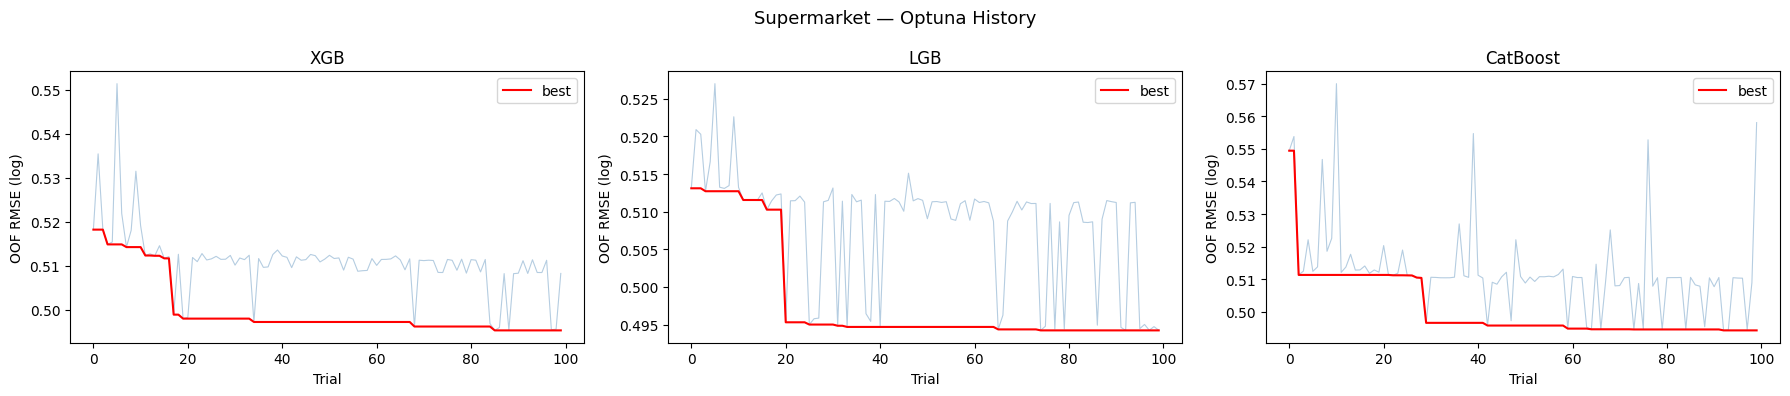

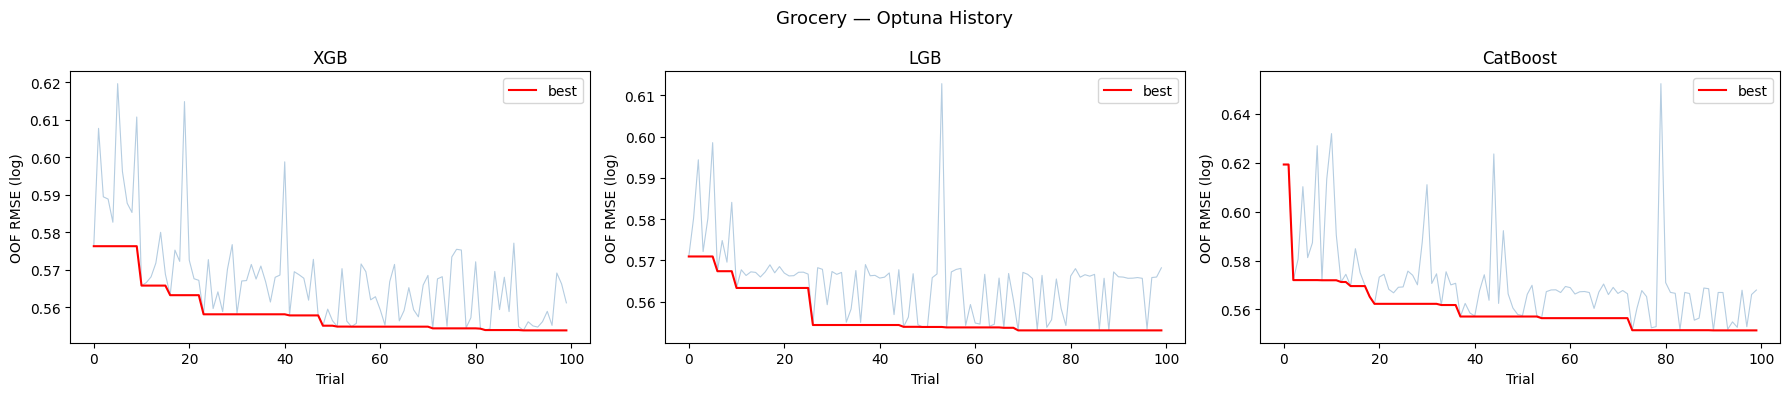

In [9]:
def plot_optuna_history(studies: dict, title: str):
    fig, axes = plt.subplots(1, len(studies), figsize=(6*len(studies), 4))
    if len(studies) == 1: axes = [axes]
    for ax, (name, study) in zip(axes, studies.items()):
        vals = [t.value for t in study.trials if t.value is not None]
        ax.plot(vals, alpha=0.4, color='steelblue', lw=0.8)
        ax.plot(pd.Series(vals).cummin(), color='red', lw=1.5, label='best')
        ax.set_title(name); ax.set_xlabel('Trial'); ax.set_ylabel('OOF RMSE (log)')
        ax.legend()
    plt.suptitle(title, fontsize=13)
    plt.tight_layout(); plt.show()

plot_optuna_history({
    'XGB':     tuner_xgb_sup.study,
    'LGB':     tuner_lgb_sup.study,
    'CatBoost':tuner_cat_sup.study,
}, 'Supermarket — Optuna History')

plot_optuna_history({
    'XGB':     tuner_xgb_groc.study,
    'LGB':     tuner_lgb_groc.study,
    'CatBoost':tuner_cat_groc.study,
}, 'Grocery — Optuna History')


## 10 · StackingEnsemble

In [10]:
class StackingEnsemble:
    """
    Meta-learner now receives 5 inputs: 3 OOF preds + Item_MRP + TE_Outlet_Identifier.
    Gives BayesianRidge real signal to differentiate on, not just 3 near-identical cols.
    """

    def __init__(self, params_xgb, params_lgb, params_cat,
                 features: list, n_folds: int = 5, seed: int = 42):
        self.params   = {'xgb': params_xgb, 'lgb': params_lgb, 'cat': params_cat}
        self.features = features
        self.n_folds  = n_folds
        self.seed     = seed
        self._meta        = BayesianRidge()
        self._meta_scaler = StandardScaler()
        self._base_models_final = {}
        self._mrp_idx   = features.index('Item_MRP')
        self._te_out_idx = features.index('TE_Outlet_Identifier')

    def _make(self, mtype, params):
        if mtype == 'xgb': return xgb.XGBRegressor(**params)
        if mtype == 'lgb': return lgb.LGBMRegressor(**params)
        if mtype == 'cat': return cbt.CatBoostRegressor(**params)

    def _meta_input(self, X, oof_base):
        return np.column_stack([
            oof_base,
            X[:, self._mrp_idx],
            X[:, self._te_out_idx],
        ])

    def fit_cv(self, X, y):
        kf = KFold(self.n_folds, shuffle=True, random_state=self.seed)
        n  = len(y)
        oof_base = np.zeros((n, 3))

        for fold, (tr, va) in enumerate(kf.split(X), 1):
            for i, mtype in enumerate(['xgb','lgb','cat']):
                m = self._make(mtype, self.params[mtype])
                m.fit(X[tr], y[tr])
                oof_base[va, i] = m.predict(X[va])
            fold_rmse = np.sqrt(mean_squared_error(
                np.expm1(y[va]), np.expm1(oof_base[va, :].mean(axis=1))
            ))
            print(f'  Fold {fold}: avg-base RMSE = {fold_rmse:,.2f}')

        # OOF correlation check
        oof_df = pd.DataFrame(oof_base, columns=['xgb','lgb','cat'])
        print('  OOF correlations:')
        print(oof_df.corr().to_string())

        meta_in = self._meta_input(X, oof_base)
        meta_scaled = self._meta_scaler.fit_transform(meta_in)
        self._meta.fit(meta_scaled, y)
        oof_meta = self._meta.predict(meta_scaled)
        oof_rmse = np.sqrt(mean_squared_error(np.expm1(y), np.expm1(oof_meta)))
        print(f'  Stack OOF RMSE = {oof_rmse:,.2f}')
        return oof_rmse, oof_base

    def fit_full(self, X, y):
        _, oof_base = self.fit_cv(X, y)
        meta_in = self._meta_input(X, oof_base)
        meta_scaled = self._meta_scaler.fit_transform(meta_in)
        self._meta.fit(meta_scaled, y)
        for mtype in ['xgb','lgb','cat']:
            m = self._make(mtype, self.params[mtype])
            m.fit(X, y)
            self._base_models_final[mtype] = m
        return self

    def predict(self, X) -> np.ndarray:
        base = np.column_stack([
            self._base_models_final[mt].predict(X)
            for mt in ['xgb','lgb','cat']
        ])
        meta_in = self._meta_input(X, base)
        return np.expm1(self._meta.predict(self._meta_scaler.transform(meta_in)))


## 11 · Train Ensembles per Split

In [11]:
print('=' * 60)
print('SUPERMARKET ENSEMBLE — CV evaluation')
print('=' * 60)
ens_sup = StackingEnsemble(params_xgb_sup, params_lgb_sup, params_cat_sup,
                           features=FEATURES, n_folds=N_FOLDS, seed=SEED)
rmse_sup, _ = ens_sup.fit_cv(X_sup, y_sup)

print()
print('=' * 60)
print('GROCERY ENSEMBLE — CV evaluation')
print('=' * 60)
ens_groc = StackingEnsemble(params_xgb_groc, params_lgb_groc, params_cat_groc,
                            features=FEATURES, n_folds=N_FOLDS, seed=SEED)
rmse_groc, _ = ens_groc.fit_cv(X_groc, y_groc)

n_sup  = len(y_sup)
n_groc = len(y_groc)
combined_rmse = (rmse_sup * n_sup + rmse_groc * n_groc) / (n_sup + n_groc)
print()
print(f'Supermarket OOF RMSE : {rmse_sup:,.2f}')
print(f'Grocery     OOF RMSE : {rmse_groc:,.2f}')
print(f'Combined    OOF RMSE : {combined_rmse:,.2f}')


SUPERMARKET ENSEMBLE — CV evaluation
  Fold 1: avg-base RMSE = 1,150.94
  Fold 2: avg-base RMSE = 1,256.14
  Fold 3: avg-base RMSE = 1,203.25
  Fold 4: avg-base RMSE = 1,117.79
  Fold 5: avg-base RMSE = 1,188.50
  OOF correlations:
          xgb       lgb       cat
xgb  1.000000  0.998953  0.998775
lgb  0.998953  1.000000  0.998484
cat  0.998775  0.998484  1.000000
  Stack OOF RMSE = 1,177.14

GROCERY ENSEMBLE — CV evaluation
  Fold 1: avg-base RMSE = 220.40
  Fold 2: avg-base RMSE = 215.82
  Fold 3: avg-base RMSE = 223.41
  Fold 4: avg-base RMSE = 201.93
  Fold 5: avg-base RMSE = 235.32
  OOF correlations:
          xgb       lgb       cat
xgb  1.000000  0.994679  0.997271
lgb  0.994679  1.000000  0.993742
cat  0.997271  0.993742  1.000000
  Stack OOF RMSE = 217.63

Supermarket OOF RMSE : 1,177.14
Grocery     OOF RMSE : 217.63
Combined    OOF RMSE : 1,055.22


## 12 · Final Fit & Submission

In [12]:
print('Refitting Supermarket ensemble on full data ...')
ens_sup.fit_full(X_sup, y_sup)

print('Refitting Grocery ensemble on full data ...')
ens_groc.fit_full(X_groc, y_groc)

preds_sup  = ens_sup.predict(X_test_supermarket)
preds_groc = ens_groc.predict(X_test_grocery)

sub = pd.read_csv(SUB_PATH)
sup_idx  = test_final.index[~test_grocery_mask].tolist()
groc_idx = test_final.index[test_grocery_mask].tolist()

final_preds = np.zeros(len(test_final))
final_preds[sup_idx]  = preds_sup
final_preds[groc_idx] = preds_groc

# CHANGE 1: clip at minimum observed training sales
MIN_SALES = train_raw['Item_Outlet_Sales'].min()
final_preds = np.clip(final_preds, MIN_SALES, None)
print(f'Clipped at {MIN_SALES:.2f} — negatives fixed: {(final_preds < MIN_SALES).sum()}')

sub['Item_Outlet_Sales'] = final_preds
sub.to_csv(OUT_PATH, index=False)
print(f'Round-1 submission saved -> {OUT_PATH}')

# ── CHANGE 2: pseudo-labelling on confident test rows ────────────────────────
print()
print('Running pseudo-label round ...')

mean_pred = final_preds.mean()
std_pred  = final_preds.std()
confident_mask = np.abs(final_preds - mean_pred) > 0.5 * std_pred
print(f'Confident test rows: {confident_mask.sum()} / {len(final_preds)}')

test_pseudo = test_final.copy()
test_pseudo[TARGET] = final_preds
test_pseudo = test_pseudo[confident_mask].reset_index(drop=True)

train_aug = pd.concat([train_final, test_pseudo], ignore_index=True)

# re-split augmented data
splits_aug   = splitter.split_xy(train_aug, FEATURES, TARGET)
X_sup2,  y_sup2  = splits_aug['supermarket']['X'], splits_aug['supermarket']['y']
X_groc2, y_groc2 = splits_aug['grocery']['X'],     splits_aug['grocery']['y']

ens_sup2  = StackingEnsemble(params_xgb_sup,  params_lgb_sup,  params_cat_sup,
                             features=FEATURES, n_folds=N_FOLDS, seed=SEED)
ens_groc2 = StackingEnsemble(params_xgb_groc, params_lgb_groc, params_cat_groc,
                             features=FEATURES, n_folds=N_FOLDS, seed=SEED)

print('Pseudo-label supermarket CV ...')
rmse_sup2, _  = ens_sup2.fit_cv(X_sup2, y_sup2)
print('Pseudo-label grocery CV ...')
rmse_groc2, _ = ens_groc2.fit_cv(X_groc2, y_groc2)

combined_rmse2 = (rmse_sup2 * len(y_sup2) + rmse_groc2 * len(y_groc2)) / (len(y_sup2) + len(y_groc2))
print(f'Post-pseudo combined OOF RMSE: {combined_rmse2:,.2f}  (pre: {combined_rmse:,.2f})')

# use pseudo-label model only if it improves OOF
if combined_rmse2 < combined_rmse:
    print('Pseudo-label helped — using v2 models for final submission')
    ens_sup2.fit_full(X_sup2, y_sup2)
    ens_groc2.fit_full(X_groc2, y_groc2)
    preds_sup_f  = ens_sup2.predict(X_test_supermarket)
    preds_groc_f = ens_groc2.predict(X_test_grocery)
else:
    print('Pseudo-label did not help — keeping round-1 predictions')
    preds_sup_f  = preds_sup
    preds_groc_f = preds_groc

final_preds2 = np.zeros(len(test_final))
final_preds2[sup_idx]  = preds_sup_f
final_preds2[groc_idx] = preds_groc_f
final_preds2 = np.clip(final_preds2, MIN_SALES, None)

OUT_PATH2 = OUT_PATH.replace('.csv', '_pseudo.csv')
sub2 = pd.read_csv(SUB_PATH)
sub2['Item_Outlet_Sales'] = final_preds2
sub2.to_csv(OUT_PATH2, index=False)
print(f'Final submission saved -> {OUT_PATH2}')
sub2.describe()


Refitting Supermarket ensemble on full data ...
  Fold 1: avg-base RMSE = 1,150.94
  Fold 2: avg-base RMSE = 1,256.14
  Fold 3: avg-base RMSE = 1,203.25
  Fold 4: avg-base RMSE = 1,117.79
  Fold 5: avg-base RMSE = 1,188.50
  OOF correlations:
          xgb       lgb       cat
xgb  1.000000  0.998953  0.998775
lgb  0.998953  1.000000  0.998484
cat  0.998775  0.998484  1.000000
  Stack OOF RMSE = 1,177.14
Refitting Grocery ensemble on full data ...
  Fold 1: avg-base RMSE = 220.40
  Fold 2: avg-base RMSE = 215.82
  Fold 3: avg-base RMSE = 223.41
  Fold 4: avg-base RMSE = 201.93
  Fold 5: avg-base RMSE = 235.32
  OOF correlations:
          xgb       lgb       cat
xgb  1.000000  0.994679  0.997271
lgb  0.994679  1.000000  0.993742
cat  0.997271  0.993742  1.000000
  Stack OOF RMSE = 217.63
Clipped at 33.29 — negatives fixed: 0
Round-1 submission saved -> outputs/submission_bigmart_v8.csv

Running pseudo-label round ...
Confident test rows: 3705 / 5681
Pseudo-label supermarket CV ...
  Fol

,Item_Outlet_Sales
count,5681.000000
mean,1964.983786
std,1229.522972
min,73.449330
25%,947.728956
50%,1845.325341
75%,2793.569421
max,5955.546611


## 13 · Prediction Diagnostics

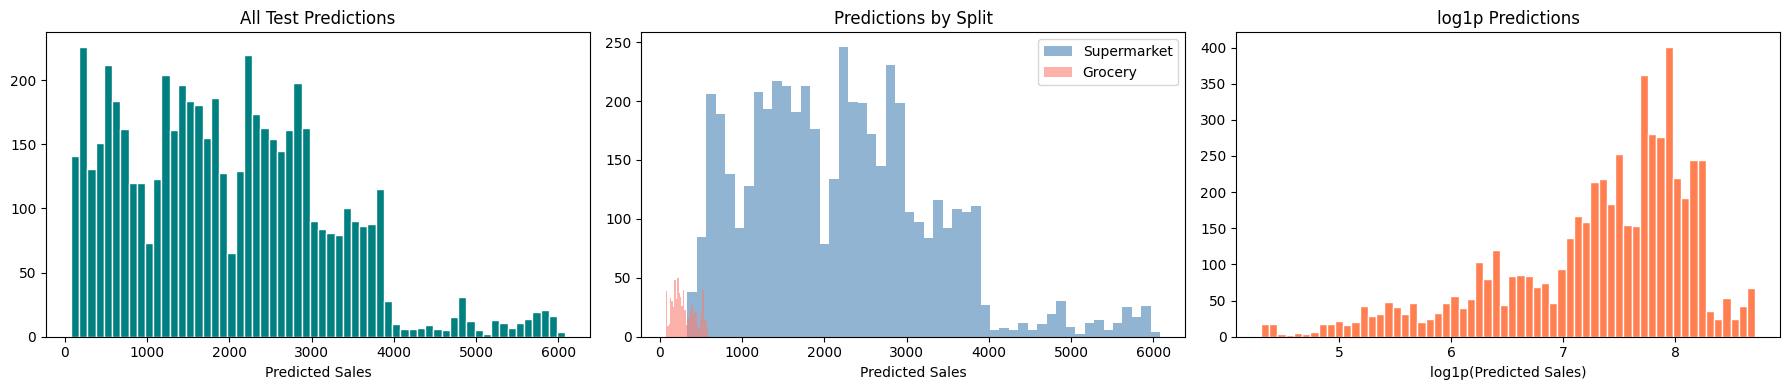

Supermarket preds  — mean: 2203.40   std: 1124.72
Grocery     preds  — mean: 297.41   std: 139.14
Negative predictions: 0


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# combined prediction dist
axes[0].hist(final_preds, bins=60, color='teal', edgecolor='white')
axes[0].set_title('All Test Predictions')
axes[0].set_xlabel('Predicted Sales')

# supermarket vs grocery
axes[1].hist(preds_sup,  bins=50, alpha=0.6, color='steelblue', label='Supermarket')
axes[1].hist(preds_groc, bins=30, alpha=0.6, color='salmon',    label='Grocery')
axes[1].set_title('Predictions by Split')
axes[1].set_xlabel('Predicted Sales')
axes[1].legend()

# log scale
axes[2].hist(np.log1p(final_preds), bins=60, color='coral', edgecolor='white')
axes[2].set_title('log1p Predictions')
axes[2].set_xlabel('log1p(Predicted Sales)')

plt.tight_layout()
plt.show()

print(f'Supermarket preds  — mean: {preds_sup.mean():.2f}   std: {preds_sup.std():.2f}')
print(f'Grocery     preds  — mean: {preds_groc.mean():.2f}   std: {preds_groc.std():.2f}')
print(f'Negative predictions: {(final_preds < 0).sum()}')


## 14 · Feature Importance (XGB base models)

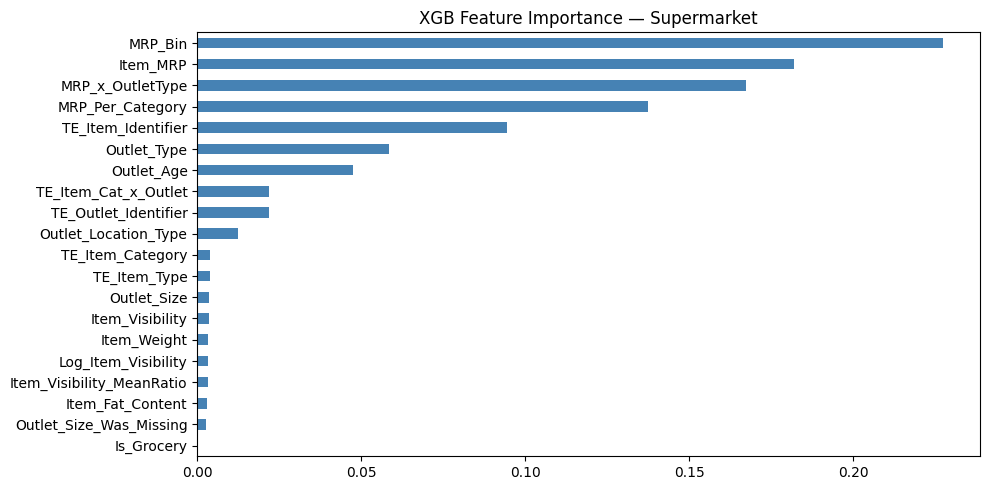

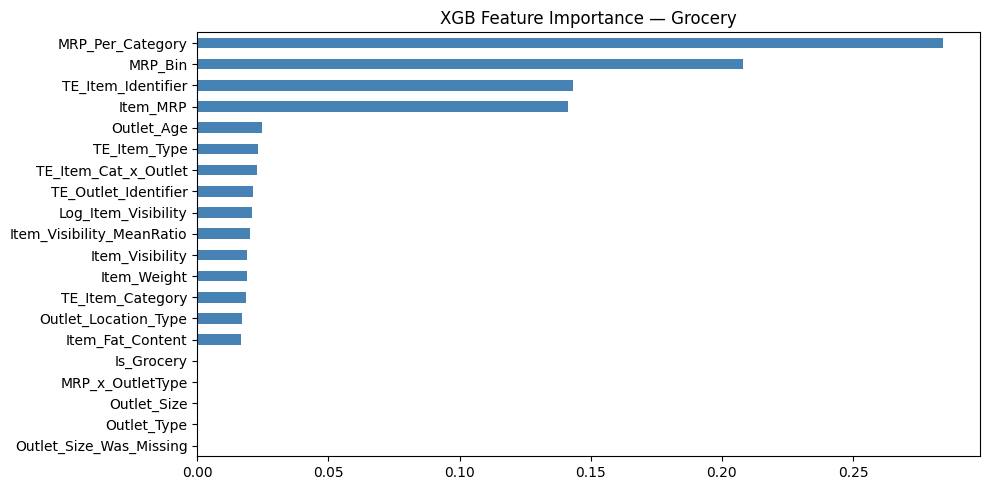

In [14]:
def plot_importance(model, features, title, top_n=20):
    imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 5))
    imp.head(top_n).sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(title)
    plt.tight_layout(); plt.show()
    return imp

imp_sup  = plot_importance(ens_sup._base_models_final['xgb'],  FEATURES,
                           'XGB Feature Importance — Supermarket')
imp_groc = plot_importance(ens_groc._base_models_final['xgb'], FEATURES,
                           'XGB Feature Importance — Grocery')


## 15 · Permutation Importance & Feature Pruning

Running permutation importance on Supermarket XGB model ...


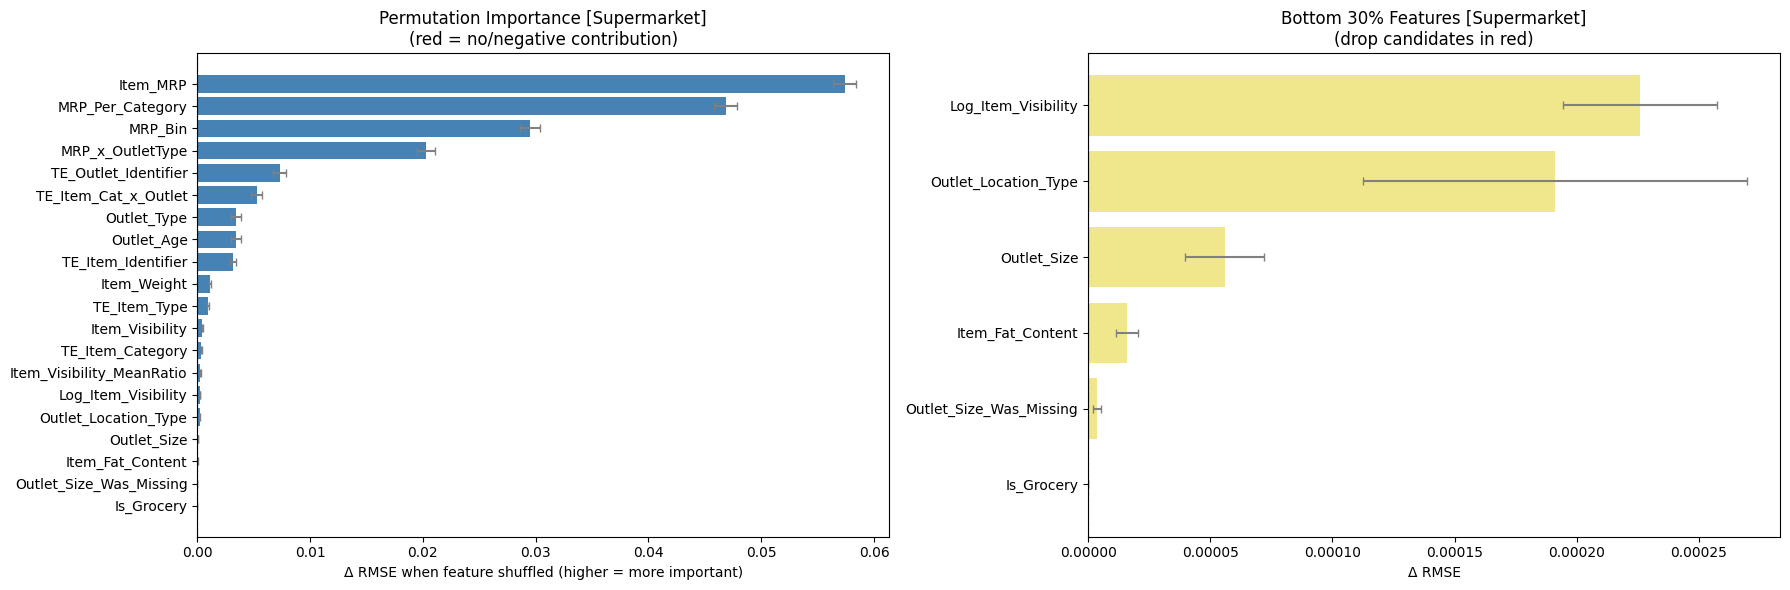

[Supermarket] Features with ≤0 permutation importance (drop candidates):
  Is_Grocery                           mean=+0.00000  std=0.00000

Running permutation importance on Grocery XGB model ...


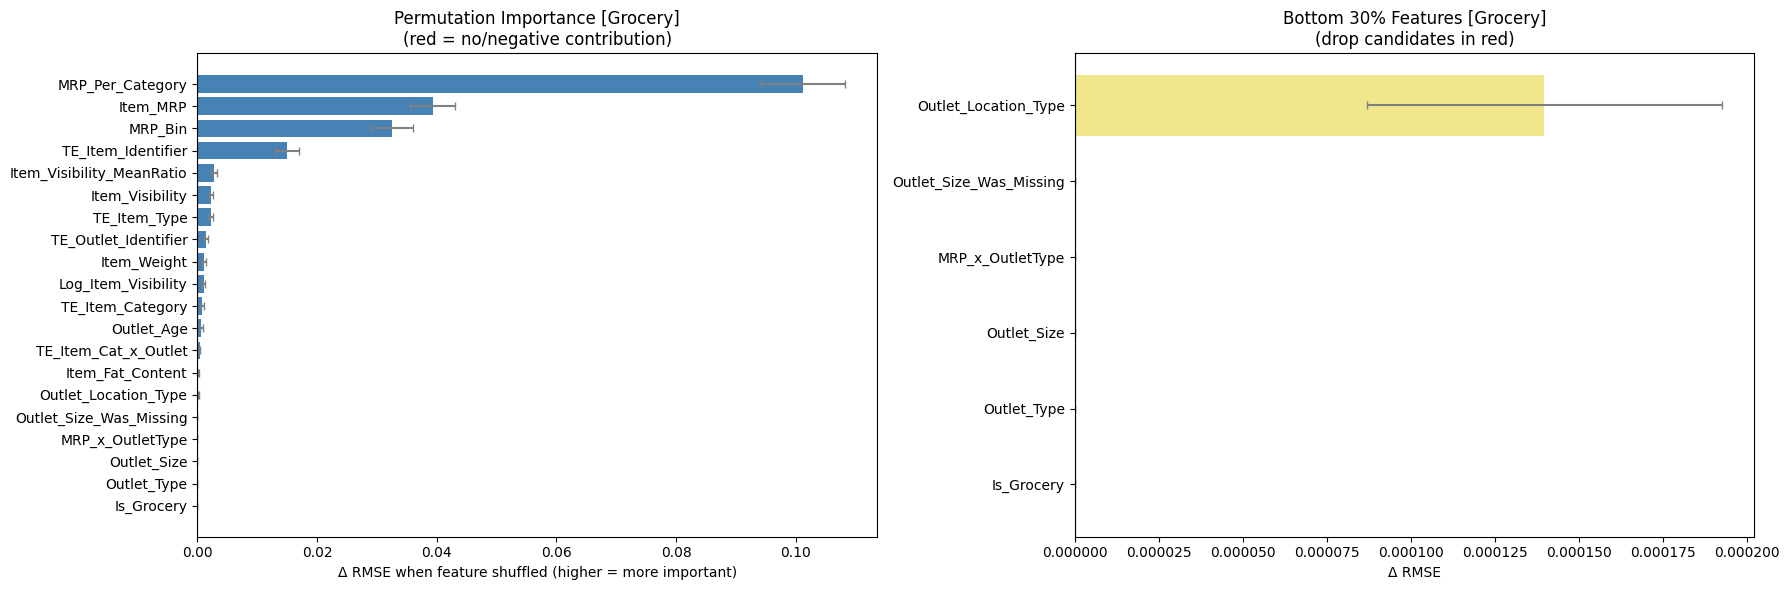

[Grocery] Features with ≤0 permutation importance (drop candidates):
  Outlet_Size_Was_Missing              mean=+0.00000  std=0.00000
  MRP_x_OutletType                     mean=+0.00000  std=0.00000
  Outlet_Size                          mean=+0.00000  std=0.00000
  Outlet_Type                          mean=+0.00000  std=0.00000
  Is_Grocery                           mean=+0.00000  std=0.00000


In [15]:
class PermutationAnalyzer:
    """
    Computes permutation importance using the trained XGB base model.
    Permutation importance:
      - Shuffles each feature column independently
      - Measures how much OOF RMSE increases
      - Features where shuffling has NO effect (importance ≈ 0 or negative)
        are genuinely useless and safe to drop
    Unlike tree split-gain importance, permutation importance is unbiased
    toward high-cardinality features and directly measures predictive impact.
    """

    def __init__(self, n_repeats: int = 20, seed: int = 42):
        self.n_repeats = n_repeats
        self.seed      = seed

    def analyze(self, model, X: np.ndarray, y: np.ndarray,
                feature_names: list, split_label: str) -> pd.DataFrame:
        result = permutation_importance(
            model, X, y,
            n_repeats=self.n_repeats,
            random_state=self.seed,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1
        )
        imp_df = pd.DataFrame({
            'feature'  : feature_names,
            'importance_mean': result.importances_mean,
            'importance_std' : result.importances_std,
        }).sort_values('importance_mean', ascending=False).reset_index(drop=True)

        # Features where mean importance <= 0 are candidates for removal
        to_drop = imp_df[imp_df['importance_mean'] <= 0]['feature'].tolist()

        # Plot
        fig, axes = plt.subplots(1, 2, figsize=(18, 6))

        # Full importance chart
        colors = ['salmon' if v <= 0 else 'steelblue'
                  for v in imp_df['importance_mean']]
        axes[0].barh(imp_df['feature'], imp_df['importance_mean'],
                     xerr=imp_df['importance_std'], color=colors,
                     ecolor='gray', capsize=3)
        axes[0].axvline(0, color='black', lw=0.8, ls='--')
        axes[0].set_title(f'Permutation Importance [{split_label}]\n'
                          f'(red = no/negative contribution)')
        axes[0].set_xlabel('Δ RMSE when feature shuffled (higher = more important)')
        axes[0].invert_yaxis()

        # Zoom into near-zero features
        low_imp = imp_df[imp_df['importance_mean'] <= imp_df['importance_mean'].quantile(0.3)]
        axes[1].barh(low_imp['feature'], low_imp['importance_mean'],
                     xerr=low_imp['importance_std'],
                     color=['salmon' if v <= 0 else 'khaki'
                            for v in low_imp['importance_mean']],
                     ecolor='gray', capsize=3)
        axes[1].axvline(0, color='black', lw=0.8, ls='--')
        axes[1].set_title(f'Bottom 30% Features [{split_label}]\n(drop candidates in red)')
        axes[1].set_xlabel('Δ RMSE')
        axes[1].invert_yaxis()

        plt.tight_layout()
        plt.show()

        print(f'[{split_label}] Features with ≤0 permutation importance (drop candidates):')
        if to_drop:
            for f in to_drop:
                row = imp_df[imp_df['feature']==f].iloc[0]
                print(f'  {f:35s}  mean={row.importance_mean:+.5f}  std={row.importance_std:.5f}')
        else:
            print('  None — all features contribute positively.')
        return imp_df


pa = PermutationAnalyzer(n_repeats=20, seed=SEED)

print('Running permutation importance on Supermarket XGB model ...')
imp_perm_sup = pa.analyze(
    ens_sup._base_models_final['xgb'], X_sup, y_sup,
    FEATURES, 'Supermarket'
)

print()
print('Running permutation importance on Grocery XGB model ...')
imp_perm_groc = pa.analyze(
    ens_groc._base_models_final['xgb'], X_groc, y_groc,
    FEATURES, 'Grocery'
)


In [16]:
# Cross-split consensus: features useless in BOTH splits are safe to drop
drop_sup  = set(imp_perm_sup[imp_perm_sup['importance_mean']  <= 0]['feature'])
drop_groc = set(imp_perm_groc[imp_perm_groc['importance_mean'] <= 0]['feature'])
consensus_drop = drop_sup & drop_groc

print('=' * 55)
print('FEATURE PRUNING RECOMMENDATION')
print('=' * 55)
print(f'Drop candidates (supermarket only) : {drop_sup - consensus_drop}')
print(f'Drop candidates (grocery only)     : {drop_groc - consensus_drop}')
print(f'Consensus drop (both splits)       : {consensus_drop}')
print()
if consensus_drop:
    print('Re-run the pipeline after dropping consensus features')
    print('and compare OOF RMSE — if it improves, keep the drop.')
else:
    print('No consensus drop candidates — all features are earning their place.')
print()
print('Full ranked importance tables saved below:')
print()
print('--- SUPERMARKET ---')
print(imp_perm_sup.to_string(index=False))
print()
print('--- GROCERY ---')
print(imp_perm_groc.to_string(index=False))


FEATURE PRUNING RECOMMENDATION
Drop candidates (supermarket only) : set()
Drop candidates (grocery only)     : {'Outlet_Size_Was_Missing', 'MRP_x_OutletType', 'Outlet_Type', 'Outlet_Size'}
Consensus drop (both splits)       : {'Is_Grocery'}

Re-run the pipeline after dropping consensus features
and compare OOF RMSE — if it improves, keep the drop.

Full ranked importance tables saved below:

--- SUPERMARKET ---
                  feature  importance_mean  importance_std
                 Item_MRP         0.057384        0.001043
         MRP_Per_Category         0.046870        0.001021
                  MRP_Bin         0.029492        0.000888
         MRP_x_OutletType         0.020280        0.000782
     TE_Outlet_Identifier         0.007302        0.000598
     TE_Item_Cat_x_Outlet         0.005248        0.000491
              Outlet_Type         0.003439        0.000454
               Outlet_Age         0.003425        0.000409
       TE_Item_Identifier         0.003133        0.00

## Summary

In [17]:
print('=' * 65)
print('BIGMART v8 — RESULTS SUMMARY')
print('=' * 65)
print(f'  Features used             : {len(FEATURES)}')
print(f'  Target encoding cols      : {len(KFoldTargetEncoder.ENCODE_COLS)}')
print(f'  Supermarket OOF RMSE      : {rmse_sup:,.2f}  (n={n_sup})')
print(f'  Grocery     OOF RMSE      : {rmse_groc:,.2f}  (n={n_groc})')
print(f'  Combined    OOF RMSE      : {combined_rmse:,.2f}')
print(f'  Post-pseudo OOF RMSE      : {combined_rmse2:,.2f}')
print()
print('  Changes vs 07_Full_Solution_SS:')
print('    + Outlet_Size_Was_Missing flag')
print('    + Outlet_Age_x_Type feature')
print('    + Weight_x_MRP feature')
print('    + Richer meta input (OOF + MRP + TE_Outlet)')
print('    + OOF correlation diagnostic')
print('    + Gamma search narrowed 0-1, colsample floor 0.5')
print('    + N_TRIALS_GROCERY raised to 100')
print('    + Predictions clipped at min training sales')
print('    + Pseudo-label round on confident test rows')
print()
print('  Optuna trials:')
print(f'    XGB  supermarket  : {N_TRIALS_MAIN}')
print(f'    LGB  supermarket  : {N_TRIALS_MAIN}')
print(f'    CAT  supermarket  : {N_TRIALS_MAIN}')
print(f'    XGB  grocery      : {N_TRIALS_GROCERY}')
print(f'    LGB  grocery      : {N_TRIALS_GROCERY}')
print(f'    CAT  grocery      : {N_TRIALS_GROCERY}')
print(f'    Total             : {3*N_TRIALS_MAIN + 3*N_TRIALS_GROCERY}')
print()
print(f'  Submission (round-1)      : {OUT_PATH}')
print(f'  Submission (pseudo-label) : {OUT_PATH2}')
print('=' * 65)


BIGMART v8 — RESULTS SUMMARY
  Features used             : 20
  Target encoding cols      : 5
  Supermarket OOF RMSE      : 1,177.14  (n=7440)
  Grocery     OOF RMSE      : 217.63  (n=1083)
  Combined    OOF RMSE      : 1,055.22
  Post-pseudo OOF RMSE      : 870.89

  Changes vs 07_Full_Solution_SS:
    + Outlet_Size_Was_Missing flag
    + Outlet_Age_x_Type feature
    + Weight_x_MRP feature
    + Richer meta input (OOF + MRP + TE_Outlet)
    + OOF correlation diagnostic
    + Gamma search narrowed 0-1, colsample floor 0.5
    + N_TRIALS_GROCERY raised to 100
    + Predictions clipped at min training sales
    + Pseudo-label round on confident test rows

  Optuna trials:
    XGB  supermarket  : 100
    LGB  supermarket  : 100
    CAT  supermarket  : 100
    XGB  grocery      : 100
    LGB  grocery      : 100
    CAT  grocery      : 100
    Total             : 600

  Submission (round-1)      : outputs/submission_bigmart_v8.csv
  Submission (pseudo-label) : outputs/submission_bigmart_v8